a = 7.749623, b = 4.081554


/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_62388/1976108821.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(z, stats.beta.pdf(z, a1, b1), 'r-', lw=2, alpha=0.6, label='beta pdf', color='orange')
/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_62388/1976108821.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(z, stats.beta.pdf(z, a2, b2), 'g-', lw=2, alpha=0.6, label='beta pdf', color='green')
/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_62388/1976108821.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(z, stats.beta.pdf(z, a, b), 'b-', lw=3, alpha=0.8, label='beta pdf', color

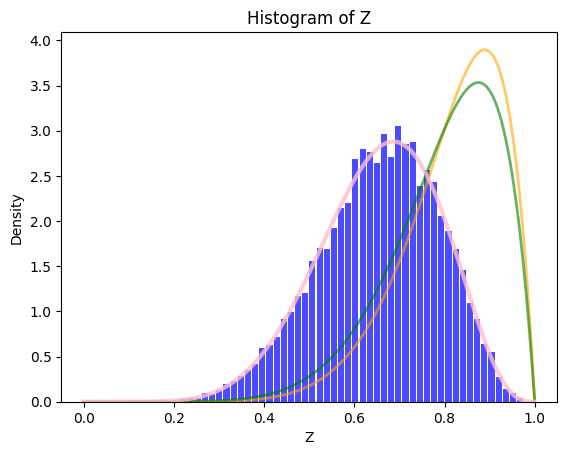

In [10]:
# generate N samples of a random variable x with beta(a, b) distribution

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

#pamaeters  
a1, b1, a2, b2 =9, 2, 8, 2
N =10000

#generate samples
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z =x*y

#use MLE to estimate the parameters of the beta distribution from Z
a, b, loc, scale = stats.beta.fit(Z, floc=0, fscale=1)
print('a = %f, b = %f' %(a, b) )
  
z = np.linspace(0, 1, 1000)
plt.plot(z, stats.beta.pdf(z, a1, b1), 'r-', lw=2, alpha=0.6, label='beta pdf', color='orange')
plt.plot(z, stats.beta.pdf(z, a2, b2), 'g-', lw=2, alpha=0.6, label='beta pdf', color='green')
plt.plot(z, stats.beta.pdf(z, a, b), 'b-', lw=3, alpha=0.8, label='beta pdf', color='pink')    
plt.hist(Z, bins=50, density=True, color='b', alpha=0.7, rwidth=0.85)
plt.title('Histogram of Z')
plt.xlabel('Z')
plt.ylabel('Density')
plt.show()


In [12]:
def unit_serial(a1, b1, a2, b2):
    #generate samples
    N = 50000
    x = np.random.beta(a1, b1, N)
    y = np.random.beta(a2, b2, N)
    Z =x*y

    a, b, loc, scale = stats.beta.fit(Z, method = 'MM', floc=0, fscale=1)
    return a, b

a1, b1, a2, b2 =9, 2, 8, 2  
a, b = unit_serial(a1, b1, a2, b2)
print('a = %f, b = %f' %(a, b) )



a = 7.688010, b = 4.054490


In [ ]:
def f(z):
    fxy = lambda y : f(z)= fy(y) * fx(z / y) / y
    

In [13]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad

# 參數
a1, b1, a2, b2 = 9, 2, 8, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z = x * y

# 使用 MLE 估計 Z 的 Beta 分佈參數
a_mle, b_mle, loc, scale = stats.beta.fit(Z, floc=0, fscale=1)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 定義 f(z) 函數
def f(z):
    integrand = lambda y: stats.beta.pdf(y, a2, b2) * stats.beta.pdf(z / y, a1, b1) / y
    result, _ = quad(integrand, z, 1)
    return result

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 1)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

MLE estimates: a = 7.668610, b = 4.035756
Optimal parameters: a = 7.620093096544278, b = 4.025266762505314


In [1]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad

# 參數
a1, b1, a2, b2 = 9, 2, 8, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z = x * y

# 使用 MLE 估計 Z 的 Beta 分佈參數
a_mle, b_mle, loc, scale = stats.beta.fit(Z, floc=0, fscale=1)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 定義 f(z) 函數
def f(z):
    integrand = lambda y: stats.beta.pdf(y, a2, b2) * stats.beta.pdf(z / y, a1, b1) / y
    result, _ = quad(integrand, z, 1)
    return result

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 1)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

MLE estimates: a = 7.686091, b = 4.066252
Optimal parameters: a = 7.620093096544278, b = 4.025266762505314


In [2]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad

# 參數
a1, b1, a2, b2 = 9, 2, 8, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z = x * y

# 使用 MLE 估計 Z 的 Beta 分佈參數
a_mle, b_mle, loc, scale = stats.beta.fit(Z, floc=0, fscale=1)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 定義 f(z) 函數
def f(z):
    integrand = lambda y: stats.beta.pdf(y, a2, b2) * stats.beta.pdf(z / y, a1, b1) / y
    result, _ = quad(integrand, z, 1)
    return result

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 1)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 使用 scipy.stats.beta.fit 進行 Method of Moments 估計
a_mm_scipy, b_mm_scipy, loc, scale = stats.beta.fit(Z, floc=0, fscale=1, method='MM')
print(f"Method of Moments (scipy) estimates: a = {a_mm_scipy}, b = {b_mm_scipy}")

MLE estimates: a = 7.724601, b = 4.058338
Optimal parameters: a = 7.620093096544278, b = 4.025266762505314
Method of Moments estimates: a = 7.730330119274918, b = 4.062603560042198
Method of Moments (scipy) estimates: a = 7.7303400686267825, b = 4.062608183167063


In [5]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad

# 參數
a1, b1, a2, b2 = 9, 2, 8, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z = x * y

# 使用 MLE 估計 Z 的 Beta 分佈參數
a_mle, b_mle, loc, scale = stats.beta.fit(Z, floc=0, fscale=1)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

MLE estimates: a = 7.511973, b = 3.992885
Method of Moments estimates: a = 7.4897451980486265, b = 3.9820408190096517


In [10]:
import numpy as np
import scipy.stats as stats

# 參數
a1, b1, a2, b2 = 9, 2, 8, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z = x * y

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

MLE estimates: a = 7.662759, b = 4.040222
Method of Moments estimates: a = 7.685402517818876, b = 4.0530606669189435


In [11]:
import numpy as np
import scipy.stats as stats

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

MLE estimates: a = 15.556900, b = 0.742033
Method of Moments estimates: a = 12.900524701274138, b = 0.6108669794507917


In [14]:
import numpy as np
import scipy.stats as stats

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

MLE estimates: a = 15.637264, b = 0.739862
Method of Moments estimates: a = 12.869076567433373, b = 0.6042691734112491


MLE estimates: a = 15.617341, b = 0.746590
Method of Moments estimates: a = 13.273604042749222, b = 0.6307312207209386


/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_93777/2914234875.py:48: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  result, _ = quad(integrand, 0, 1)
/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_93777/2914234875.py:48: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, _ = quad(integrand, 0, 1)


Optimal parameters: a = 4.113640404403067, b = 0.0037318168799225157


/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_93777/2914234875.py:36: RuntimeWarning: invalid value encountered in divide
  return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))


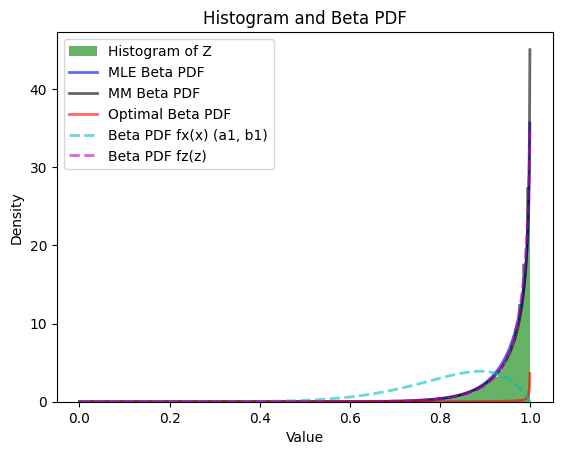

In [15]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 定義轉換後的隨機變數的分配函數 f(z)
def f(z):
    return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 1)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 繪製樣本的柱狀圖和 Beta PDF 函數線
z = np.linspace(0, 1, 1000)
plt.hist(Z, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Z')
plt.plot(z, stats.beta.pdf(z, a_mle, b_mle), 'b-', lw=2, alpha=0.6, label='MLE Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_mm, b_mm), 'k-', lw=2, alpha=0.6, label='MM Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_opt, b_opt), 'r-', lw=2, alpha=0.6, label='Optimal Beta PDF')

# 繪製 fx(x) 和 fz(z) 的 Beta PDF 函數線
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, stats.beta.pdf(x_vals, a1, b1), 'c--', lw=2, alpha=0.6, label='Beta PDF fx(x) (a1, b1)')
plt.plot(z, f(z), 'm--', lw=2, alpha=0.6, label='Beta PDF fz(z)')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Beta PDF')
plt.legend()
plt.show()

MLE estimates: a = 15.566870, b = 0.746563
Method of Moments estimates: a = 13.333018755466867, b = 0.6358069823749444


/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_93777/2914234875.py:48: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  result, _ = quad(integrand, 0, 1)
/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_93777/2914234875.py:48: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, _ = quad(integrand, 0, 1)


Optimal parameters: a = 4.113640404403067, b = 0.0037318168799225157


/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_93777/2914234875.py:36: RuntimeWarning: invalid value encountered in divide
  return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))


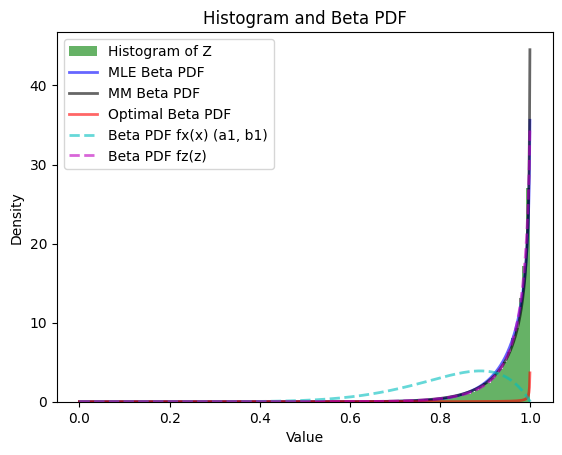

In [16]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 定義轉換後的隨機變數的分配函數 f(z)
def f(z):
    return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 1)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 繪製樣本的柱狀圖和 Beta PDF 函數線
z = np.linspace(0, 1, 1000)
plt.hist(Z, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Z')
plt.plot(z, stats.beta.pdf(z, a_mle, b_mle), 'b-', lw=2, alpha=0.6, label='MLE Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_mm, b_mm), 'k-', lw=2, alpha=0.6, label='MM Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_opt, b_opt), 'r-', lw=2, alpha=0.6, label='Optimal Beta PDF')

# 繪製 fx(x) 和 fz(z) 的 Beta PDF 函數線
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, stats.beta.pdf(x_vals, a1, b1), 'c--', lw=2, alpha=0.6, label='Beta PDF fx(x) (a1, b1)')
plt.plot(z, f(z), 'm--', lw=2, alpha=0.6, label='Beta PDF fz(z)')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Beta PDF')
plt.legend()
plt.show()

MLE estimates: a = 16.044397, b = 0.757080
Method of Moments estimates: a = 13.441967535578748, b = 0.6301209433151007
Optimal parameters: a = 14.354995047716109, b = 0.6446260449180691


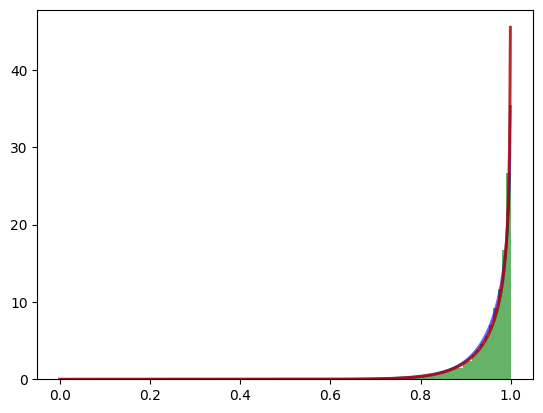

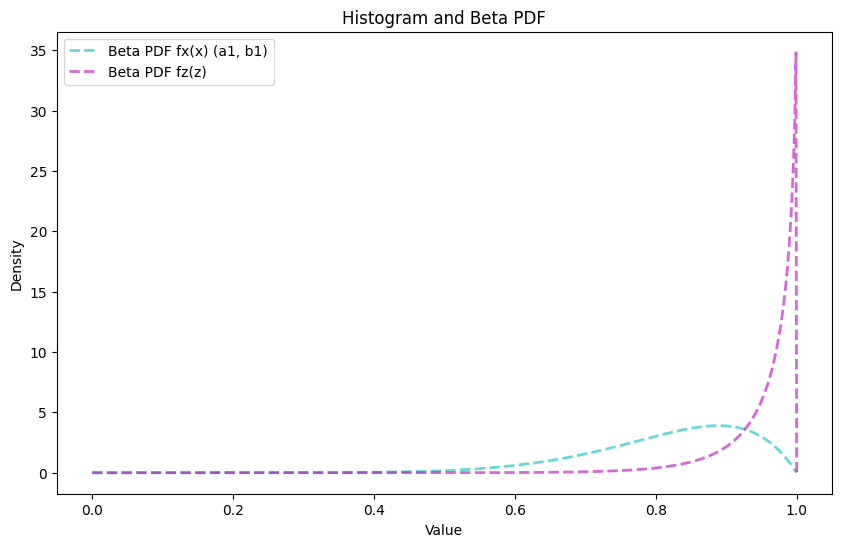

In [21]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 定義轉換後的隨機變數的分配函數 f(z)
def f(z):
    if z == 1:
        return 0  # 避免分母為零
    return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 0.95, epsabs=1e-9, epsrel=1e-9)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 繪製樣本的柱狀圖和 Beta PDF 函數線
z = np.linspace(0, 1, 1000)
plt.hist(Z, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Z')
plt.plot(z, stats.beta.pdf(z, a_mle, b_mle), 'b-', lw=2, alpha=0.6, label='MLE Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_mm, b_mm), 'k-', lw=2, alpha=0.6, label='MM Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_opt, b_opt), 'r-', lw=2, alpha=0.6, label='Optimal Beta PDF')

# 繪製 fx(x) 和 fz(z) 的 Beta PDF 函數線
#picture size
plt.figure(figsize=(10, 6))
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, stats.beta.pdf(x_vals, a1, b1), 'c--', lw=2, alpha=0.6, label='Beta PDF fx(x) (a1, b1)')
plt.plot(z, [f(val) for val in z], 'm--', lw=2, alpha=0.6, label='Beta PDF fz(z)')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Beta PDF')
plt.legend()
plt.show()

MLE estimates: a = 15.765258, b = 0.748938
Method of Moments estimates: a = 13.182549162419184, b = 0.6218323104224832
Optimal parameters: a = 14.354995047716109, b = 0.6446260449180691


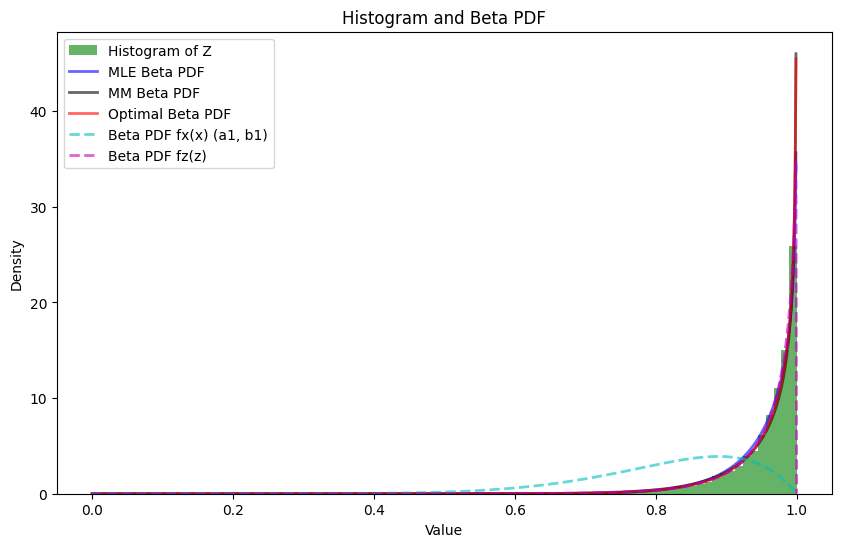

In [22]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 定義轉換後的隨機變數的分配函數 f(z)
def f(z):
    if z == 1:
        return 0  # 避免分母為零
    return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 0.95, epsabs=1e-9, epsrel=1e-9)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 繪製樣本的柱狀圖和 Beta PDF 函數線
z = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))
plt.hist(Z, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Z')
plt.plot(z, stats.beta.pdf(z, a_mle, b_mle), 'b-', lw=2, alpha=0.6, label='MLE Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_mm, b_mm), 'k-', lw=2, alpha=0.6, label='MM Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_opt, b_opt), 'r-', lw=2, alpha=0.6, label='Optimal Beta PDF')

# 繪製 fx(x) 和 fz(z) 的 Beta PDF 函數線
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, stats.beta.pdf(x_vals, a1, b1), 'c--', lw=2, alpha=0.6, label='Beta PDF fx(x) (a1, b1)')
plt.plot(z, [f(val) for val in z], 'm--', lw=2, alpha=0.6, label='Beta PDF fz(z)')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Beta PDF')
plt.legend()
plt.show()